In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import graph_print_analysis
import sys
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from swiss_roll_models.environment.dataset import generate_swiss_roll
from swiss_roll_models.environment.hilbert_distance import hilbert_analysis as hda


# positive linear model = softplus(theta) ∈ R^D_{>0}
class PositiveLinear(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(D))  # trainable parameters
    def forward(self, X):
        w = F.softplus(self.theta)
        return X @ w

    def positive_params_vector(self):
        # Return the current positive parameter vector for Hilbert distance calculation
        return F.softplus(self.theta).detach().clone()


In [2]:
def run_experiment_on_subset(
    X_full, y_full, n,
    num_epochs=500,
    lr=1e-2,
    l2_reg=1e-3,
    device="cuda"
):
    """
    Parameters
    ----------
    X_full : torch.Tensor, shape (N, D)
        Full dataset features.
    y_full : torch.Tensor, shape (N,)
        Full dataset targets.
    n : int
        Number of samples to use from the full dataset.
    num_epochs : int
        Number of training epochs.
    lr : float
        Learning rate for the optimizer.
    l2_reg : float
        L2 regularization strength.
    """
    N, D = X_full.shape
    idx = torch.randperm(N, device=device)[:n]
    X = X_full[idx]
    y = y_full[idx]

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=n, shuffle=False)  # full-batch

    model = PositiveLinear(D).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    param_traj = []
    loss_traj = []

    for epoch in range(num_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            # 1. prediction
            y_pred = model(batch_X)

            # 2. MSE part
            huber_loss = nn.SmoothL1Loss()
            mse = huber_loss(y_pred, batch_y)
        
            # 3. L2 regularization: regularize w = softplus(theta) in the positive cone
            w = F.softplus(model.theta)
            l2 = (w ** 2).sum()

            # 4. Total loss = mse + λ ||w||^2
            loss = mse + l2_reg * l2

            loss.backward()
            optimizer.step()

        loss_traj.append(loss.item())
        param_traj.append(model.positive_params_vector().cpu())

    w_star = param_traj[-1]

    return {
        "n": n,
        "loss_traj": loss_traj,
        "param_traj": param_traj,
        "w_star": w_star,
    }


In [3]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ----- Generate Swiss roll -----
N = 10_000
D = 32
X_full, y_full, u, v = generate_swiss_roll(
    n_samples=N,
    D=D,
    noise=0.0,
    device=device,
)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")

# ----- Different small sample sizes -----
n_list = [50, 100, 200, 500]
num_epochs = 500
lr = 1e-2
l2_list = [0.0, 1e-4, 1e-3, 1e-2]

result=run_experiment_on_subset(
    X_full, y_full, n=200,
    num_epochs=num_epochs,
    lr=lr,
    l2_reg=1e-3,
    device=device
)
w_star = result["w_star"]
param_traj = result["param_traj"]
loss_traj = result["loss_traj"]

Using device: cuda
Full dataset: X=torch.Size([10000, 32]), y=torch.Size([10000])


In [4]:

res=graph_print_analysis.analysis(param_traj=param_traj,path="./huber_loss_SP/",num_epochs=num_epochs,output_log='',batch_size=len(y_full),lr=lr,)




In [5]:
HTF=res["hilbert_to_final"]
RTF=res["ratios_to_final"]
RTB=res["ratios_between"]

with open('First 100 Hilbert Ratios to final '+'.txt', 'w') as f:
    for x in RTF[:100]:
        f.write(str(x) + '\n')

    

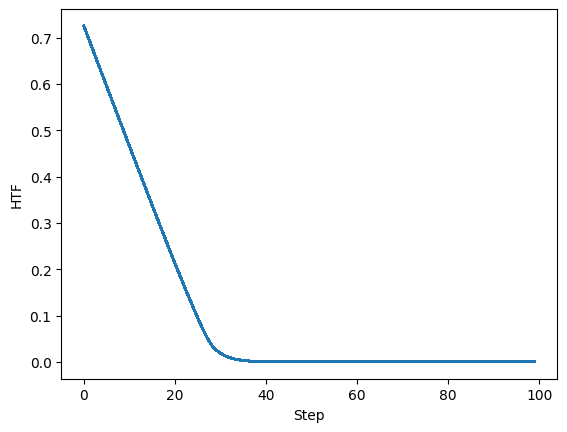

In [6]:
import matplotlib.pyplot as plt
import numpy as np
# plt.plot(range(len(HTF)), HTF)
sub_htf=HTF[:100]
plt.plot(range(len(sub_htf)), sub_htf,aa=False)
plt.xlabel("Step")
plt.ylabel("HTF")
plt.show()

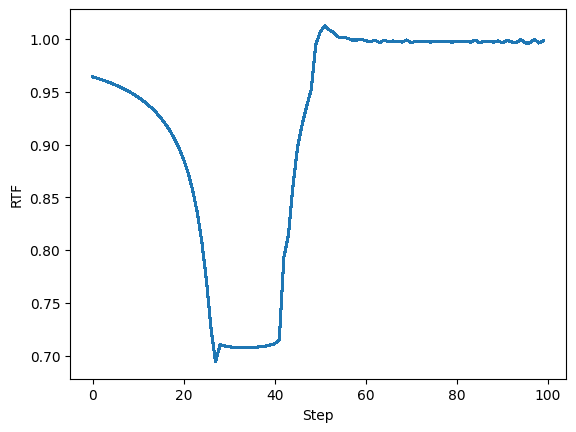

In [7]:
sub_rtf=RTF[:100]
plt.plot(range(len(sub_rtf)), sub_rtf,aa=False)
plt.xlabel("Step")
plt.ylabel("RTF")
plt.show()